In [1]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Connect to the Azure ML workspace
try:
    ml_client = MLClient.from_config(DefaultAzureCredential())

    data_asset = ml_client.data.get(name="credit_card_fraud_dataset" , version = "1")
    df = pd.read_csv(data_asset.path)
    print("Successfully loaded data from Azure Data Asset")
except Exception as e:
    print(f"Check your Data Asset name:{e}")

Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding

Successfully loaded data from Azure Data Asset


In [2]:
from sklearn.preprocessing import RobustScaler

# Convert Time (seconds) to "Hour of Day"
df['Hour'] = df['Time'].apply(lambda x : (x / 3600) % 24)

# Convert "amount" using RobustScaler
# Robust Scaler is more suitable because of massive outlier
robust_scaler = RobustScaler()
df['scaled_amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1,1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

print('Feature Engineering complete: Hour created and Amount scaled.')

Feature Engineering complete: Hour created and Amount scaled.


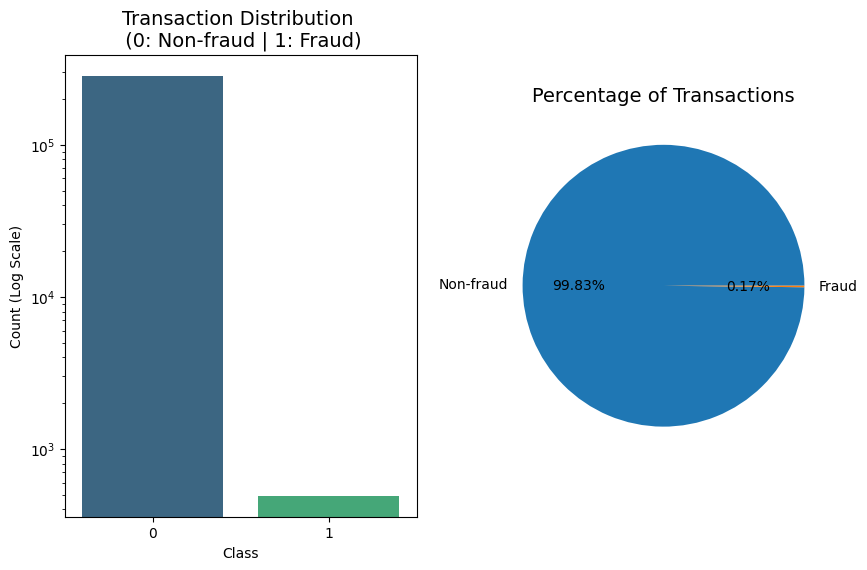

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))

# Subplot 1: Bar Chart with log scale
sns.countplot(x='Class', data=df, ax=ax[0], hue='Class', palette='viridis', legend=False)
ax[0].set_title('Transaction Distribution \n (0: Non-fraud | 1: Fraud)', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylabel('Count (Log Scale)')

# Subplot 2: pie chart for percentage
labels = ['Non-fraud', 'Fraud']
sizes = df['Class'].value_counts()
ax[1].pie(sizes, labels=labels, autopct='%1.2f%%')
ax[1].set_title('Percentage of Transactions', fontsize=14)

plt.show()

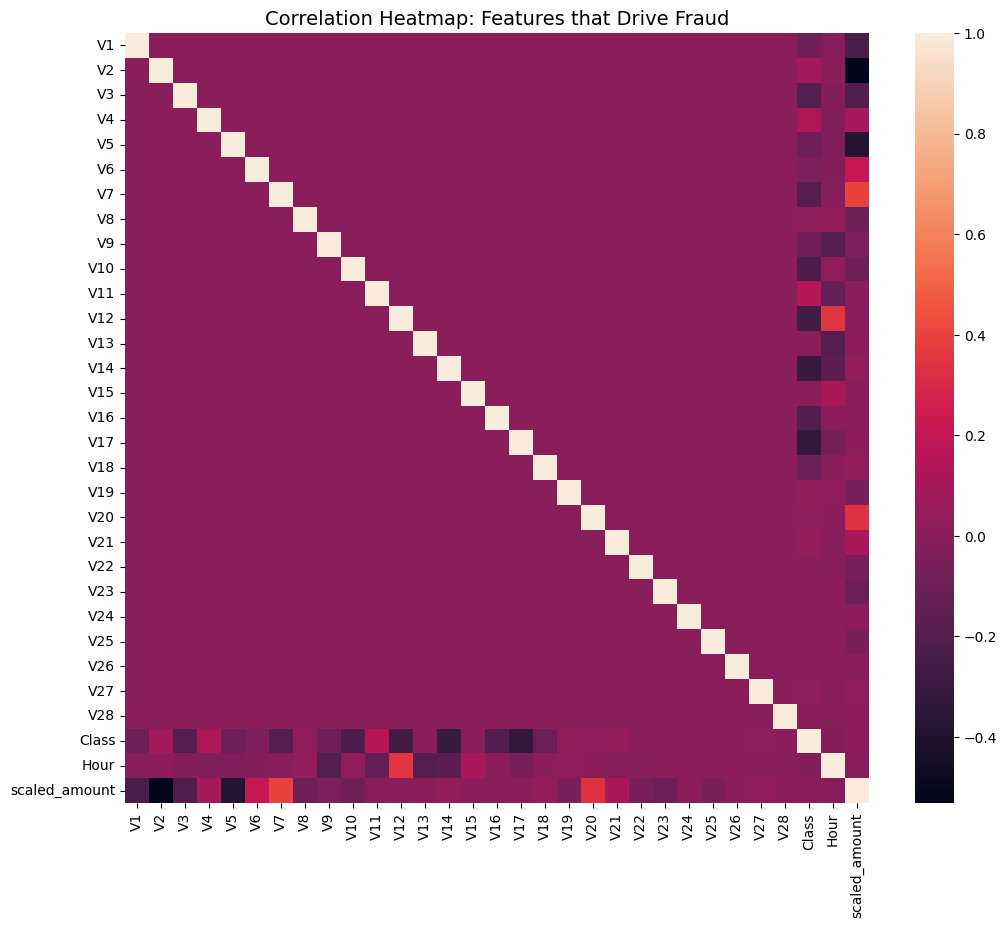

Top 5 features are: 
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [4]:
plt.figure(figsize=(12,10))

corr=df.corr()
sns.heatmap(corr, annot=False)
plt.title('Correlation Heatmap: Features that Drive Fraud', fontsize=14)
plt.show()

top_5_features = corr['Class'].abs().sort_values(ascending=False).iloc[1:6].index.to_list()
print(f"Top 5 features are: \n {corr['Class'].loc[top_5_features]}")

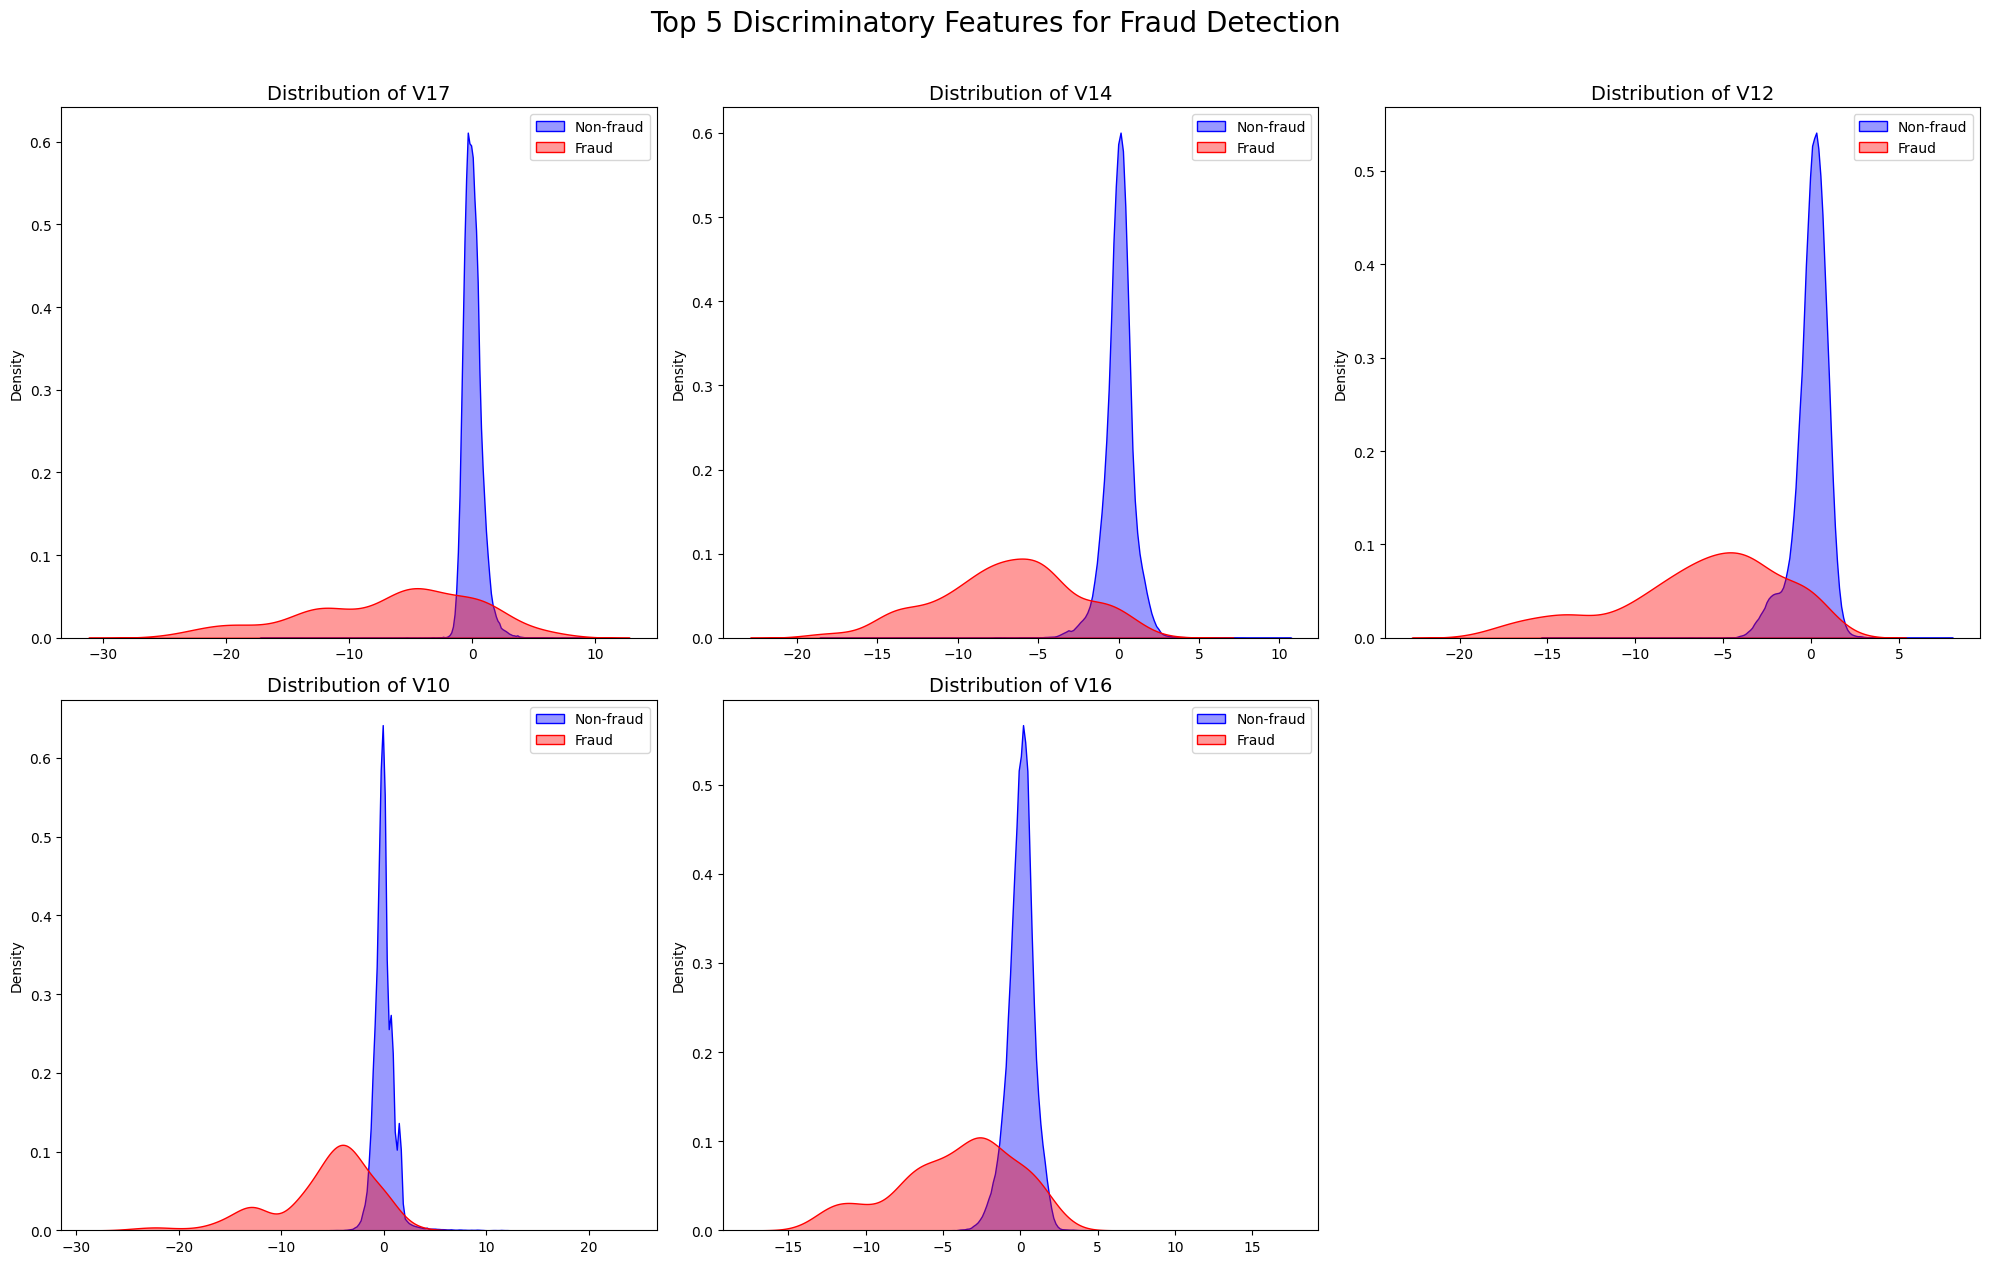

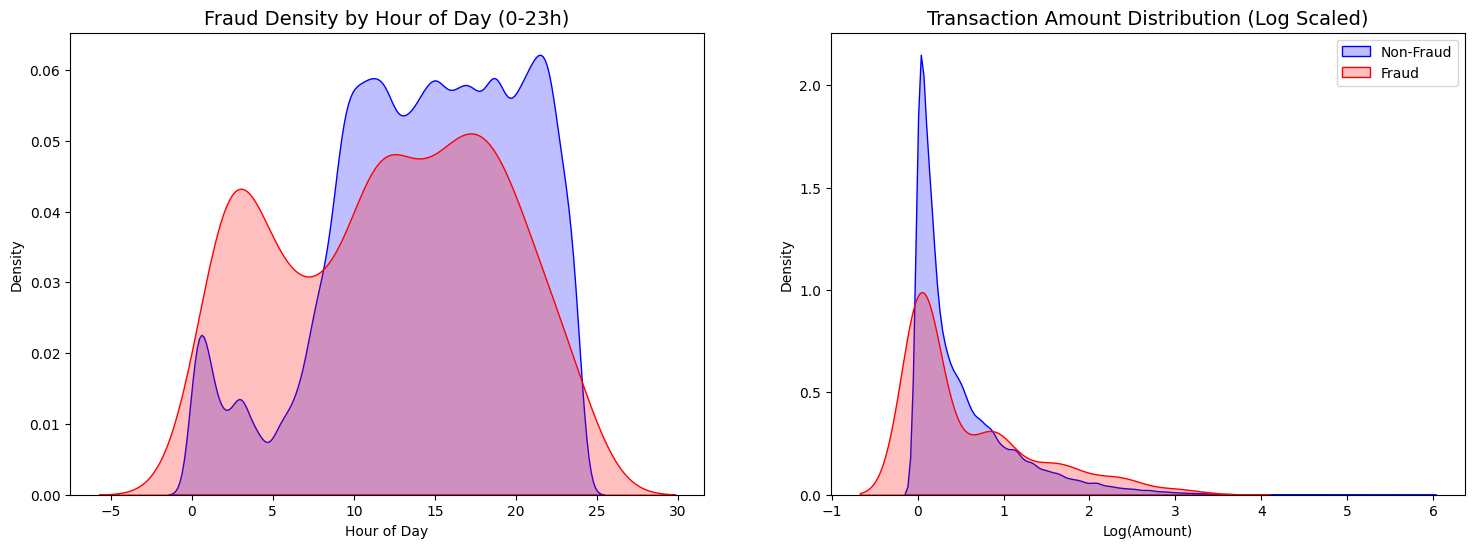

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten() # Flatten to 1D array for easy indexing

for i, feature in enumerate(top_5_features):
    # Plot Normal Transactions
    sns.kdeplot(df[df['Class'] == 0][feature], 
                ax=axes[i], 
                fill=True, 
                color='blue', 
                label='Non-fraud', 
                alpha=0.4)
    
    # Plot Fraud Transactions
    sns.kdeplot(df[df['Class'] == 1][feature], 
                ax=axes[i], 
                fill=True, 
                color='red', 
                label='Fraud', 
                alpha=0.4)
    
    axes[i].set_title(f'Distribution of {feature}', fontsize=14)
    axes[i].legend()
    axes[i].set_xlabel('')

# Remove the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('Top 5 Discriminatory Features for Fraud Detection', fontsize=20, y=1.05)

# 2. Add this specific block for the "Raw" features
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Better Time Plot: Density by Hour of Day
sns.kdeplot(df[df['Class'] == 0]['Hour'], ax=ax[0], fill=True, color='blue', label='Non-Fraud')
sns.kdeplot(df[df['Class'] == 1]['Hour'], ax=ax[0], fill=True, color='red', label='Fraud')
ax[0].set_title('Fraud Density by Hour of Day (0-23h)', fontsize=14)
ax[0].set_xlabel('Hour of Day')

# Better Amount Plot: Log-Scaled for visibility
# We use np.log1p to handle any 0.00 amounts gracefully
df['Amount_log'] = np.log1p(df['scaled_amount'] + abs(df['scaled_amount'].min())) 
sns.kdeplot(df[df['Class'] == 0]['Amount_log'], ax=ax[1], fill=True, color='blue', label='Non-Fraud')
sns.kdeplot(df[df['Class'] == 1]['Amount_log'], ax=ax[1], fill=True, color='red', label='Fraud')
ax[1].set_title('Transaction Amount Distribution (Log Scaled)', fontsize=14)
ax[1].set_xlabel('Log(Amount)')

plt.legend()
plt.show()

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

# Define our Features (X) and Target (y)
# We use the columns we engineered (scaled_amount and Hour)
X = df.drop('Class', axis=1)
y = df['Class']

# Initialize the Splitter
# 80% Training, 20% Testing
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Verify the split ratios
print(f"Training Fraud Ratio: {y_train.value_counts(normalize=True)[1]:.4%}")
print(f"Testing Fraud Ratio: {y_test.value_counts(normalize=True)[1]:.4%}")

Training Fraud Ratio: 0.1729%
Testing Fraud Ratio: 0.1720%


In [7]:
import os
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY to the Training Set
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Create a folder to store the processed data
os.makedirs('processed_data', exist_ok=True)

# Save the 3 distinct versions
# Version A: Original Imbalanced Training Data
X_train.to_csv('processed_data/X_train_imb.csv', index=False)
y_train.to_csv('processed_data/y_train_imb.csv', index=False)

# Version B: SMOTE Balanced Training Data
X_train_smote.to_csv('processed_data/X_train_smote.csv', index=False)
y_train_smote.to_csv('processed_data/y_train_smote.csv', index=False)

# Version C: The Final Test Set (Always Imbalanced/Real World)
X_test.to_csv('processed_data/X_test.csv', index=False)
y_test.to_csv('processed_data/y_test.csv', index=False)

print("Data splitting and SMOTE complete. Files saved in /processed_data")

Data splitting and SMOTE complete. Files saved in /processed_data
